In [1]:
# CELL 1 - write a larger humanized training text (~1000+ words)
text_parts = [
"""I remember the morning light falling soft across the kitchen table — a calm that always felt like permission to pause. There were small rituals: the careful grinding of beans, the hiss of the kettle, and the newspaper folded open where a cursor of sunlight landed on the travel section. Days like these felt ordinary and generous at once. Walking through the market later, I tasted mangoes that were impossibly sweet and listened to the laughter of vendors who treated every customer like an old friend.""",
"""There was a river outside the town where children jumped from a low stone wall, their shrieks of joy echoing off the water. I sat on the bank, letting the day move around me and tucked into small moments — the patient cat sleeping under a bicycle, the smell of frying onions, the way shadows stretched long and thin toward evening. When night came, lanterns blinked on and the sky warmed to a deep indigo.""",
"""Once I learned to slow down, I found meaning in details: a phrase clipped off mid-sentence, the pattern a leaf made in puddles, the way a train's whistle announced both departure and continuity. Memory is made of tiny repeated things: a phrase, a flavor, a street corner where something unexpectedly kind happened. We reconstruct our days out of such fragments.""",
"""The city had its routines. Morning commuters had a rhythm of their own — small, polite collisions of bags and umbrellas, coffee foam traced in paper cups, the soft muttered bargains at the food stall that stayed open later than it should. The old bookshop on the corner kept its flock of regulars and each volume had the light of a different afternoon pressed into its pages. I loved those afternoons when someone would recommend a book and it would feel like the beginning of a conversation that might last years.""",
"""Travel taught me how small the world can feel when you really pay attention: two strangers on a bus who became companions for an afternoon, an aunt who saved a recipe written on torn paper, the startling way new languages map to old gestures. A single kilometre of road becomes the map of many possible lives when you stick around long enough to notice the faces.""",
"""There were storms too; sudden, impressive ones that upended morning plans and made small acts of kindness necessary. Neighbours shared umbrellas, someone left a kettle on for a soaking cyclist, and we learned that the threads connecting a place are often small acts repeated until they hold you in place.""",
"""Love in this memory is not always grand. Sometimes it is the way someone remembers your favourite tea, the boot left by the door because you always misplace yours, the whispered apology that arrives exactly when things get awkward. Those pieces fit into the mosaic of ordinary affection and make it luminous.""",
"""At times the city seemed too big to hold all its histories — buildings layered atop older footprints, street names that kept changing. I liked to walk and read the layers like a book: a shop sign still clinging to an old name, a poster half-peeled, a tram route that was now a cycle track. There was history everywhere and it made the present feel like a passage between things.""",
"""Memory and language braided into each other. We used words to stitch time so that an afternoon could be told again and home could be recognized. Stories start as small things: a laugh on a balcony, a small argument over the last mango, the way the light hit a window. Then they grow into the kind of lore that lubricates living together.""",
"""When the city was quiet, I would write letters I never sent and read them under thin lamp light. The pages filled with modest confessions — that I liked the way seasons changed the park, or that a song could hold a whole day in one chord. Those private catalogs of feeling are important because they teach you how to feel carefully, how to inventory the small things that matter.""",
"""Now, if I close my eyes and think of home, it is not a single house but the geometry of daily life: a particular bench, an old coffee stain on a table, the sound of two bicycles that always pass together at the same intersection. Those are the anchors. They are not dramatic, but they are everything.""",
"""We all need anchors. They keep us from floating off into indifference. They are found in repetition: the same baker's smile, the same dog that listens to everything, the same person who waves even on rainy days. If you look carefully, you will find those anchors in the small civic rituals that stitch us together.""",
"""In the end, the most useful skill is noticing. To notice is to collect, to remember, to make a life that can be recalled and returned to. Memory is not neutral — it gives us back meaning and offers us a frame for the next small decision we will make.""",
"""This is the kind of slow, patient narration that trains an RNN or an LSTM to pick up long and short patterns in human text: recurring phrases, how sentences rhythmically unfold, and the little punctuation that signals a breath in speech. Use it to train on character and word patterns; the model will learn cadence and register if given enough data and training time."""
]

big_text = "\n\n".join(text_parts)

expanded = "\n\n".join([big_text for _ in range(3)])  # ~3x larger
with open("training_text_large.txt", "w", encoding="utf-8") as f:
    f.write(expanded)

print("Wrote training_text_large.txt; length (chars):", len(expanded))
print("Word count (approx):", len(expanded.split()))

Wrote training_text_large.txt; length (chars): 15331
Word count (approx): 2724


In [ ]:
# CELL 2 - imports and config
import os, random, json, math
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

RSEED = 42
random.seed(RSEED); np.random.seed(RSEED); tf.random.set_seed(RSEED)

TEXT_FILE = "training_text_large.txt"
SEQ_LENGTH_CHAR = 80
SEQ_LENGTH_WORD = 10
BATCH_SIZE = 64
EPOCHS_CHAR = 20
EPOCHS_WORD = 25
EMBED_DIM = 128
RNN_UNITS = 128
LSTM_UNITS = 256
VALIDATION_SPLIT = 0.1

with open(TEXT_FILE, "r", encoding="utf-8") as f:
    text = f.read()
print("Loaded text length (chars):", len(text), "words:", len(text.split()))
print("Preview:", text[:200].replace("\n"," "))

g:\My Drive\Sem 3\Deep Learning\DL Lab\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Loaded text length (chars): 15331 words: 2724
Preview: I remember the morning light falling soft across the kitchen table — a calm that always felt like permission to pause. There were small rituals: the careful grinding of beans, the hiss of the kettle, 


In [ ]:
# CELL 3 - small math working: softmax + cross-entropy for a toy logits vector
import numpy as np

logits = np.array([[2.0, 1.0, 0.1]])

exp = np.exp(logits - np.max(logits, axis=1, keepdims=True))
probs = exp / np.sum(exp, axis=1, keepdims=True)
print("logits:", logits)
print("softmax probs:", probs)

true = np.array([[1,0,0]])
eps = 1e-9
cross_entropy = -np.sum(true * np.log(probs + eps), axis=1)
print("manual cross-entropy:", cross_entropy)

import tensorflow as tf
ce_tf = tf.keras.losses.categorical_crossentropy(true.astype(np.float32), probs.astype(np.float32))
print("tf cross-entropy:", ce_tf.numpy())

logits: [[2.  1.  0.1]]
softmax probs: [[0.65900114 0.24243297 0.09856589]]
manual cross-entropy: [0.41703001]
tf cross-entropy: [0.41702998]


In [ ]:
# CELL 4 - character-level preprocessing & tf.data dataset
chars = sorted(set(text))
vocab_size_char = len(chars)
char2idx = {c:i for i,c in enumerate(chars)}
idx2char = {i:c for c,i in char2idx.items()}
print("Char vocab size:", vocab_size_char)

text_int = np.array([char2idx[c] for c in text], dtype=np.int32)

seq_length = SEQ_LENGTH_CHAR
inputs = []
targets = []
for i in range(0, len(text_int)-seq_length):
    inputs.append(text_int[i:i+seq_length])
    targets.append(text_int[i+seq_length])
inputs = np.array(inputs)
targets = np.array(targets)
print("Char sequences:", inputs.shape, "targets:", targets.shape)

dataset_char = tf.data.Dataset.from_tensor_slices((inputs, targets))
dataset_char = dataset_char.shuffle(10000).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
print("Character-level dataset ready: batches:", len(list(dataset_char.take(1))))

Char vocab size: 47
Char sequences: (15251, 80) targets: (15251,)
Character-level dataset ready: batches: 1


In [ ]:
# CELL 5 - word-level preprocessing (word tokenizer + sequences)
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts([text])
word_index = tokenizer.word_index
vocab_size_word = min(len(word_index)+1, 20000)
print("Word vocab (size):", len(word_index))

seq_words = tokenizer.texts_to_sequences([text])[0]
print("Total word tokens:", len(seq_words))

seq_len_w = SEQ_LENGTH_WORD
Xw = []
yw = []
for i in range(0, len(seq_words)-seq_len_w):
    Xw.append(seq_words[i:i+seq_len_w])
    yw.append(seq_words[i+seq_len_w])
Xw = np.array(Xw)
yw = np.array(yw)
print("Word sequences:", Xw.shape, "word targets:", yw.shape)

dataset_word = tf.data.Dataset.from_tensor_slices((Xw, yw))
dataset_word = dataset_word.shuffle(20000).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

Word vocab (size): 463
Total word tokens: 2730
Word sequences: (2720, 10) word targets: (2720,)


In [ ]:
# CELL 6 - build character-level SimpleRNN and LSTM models
from tensorflow.keras import backend as K

def build_char_rnn(vocab_size, emb_dim=EMBED_DIM, rnn_units=RNN_UNITS):
    inp = layers.Input(shape=(SEQ_LENGTH_CHAR,))
    x = layers.Embedding(vocab_size, emb_dim)(inp)
    x = layers.SimpleRNN(rnn_units, return_sequences=False)(x)
    out = layers.Dense(vocab_size, activation='softmax')(x)
    m = models.Model(inp, out)
    return m

def build_char_lstm(vocab_size, emb_dim=EMBED_DIM, lstm_units=LSTM_UNITS):
    inp = layers.Input(shape=(SEQ_LENGTH_CHAR,))
    x = layers.Embedding(vocab_size, emb_dim)(inp)
    x = layers.LSTM(lstm_units, return_sequences=False)(x)
    out = layers.Dense(vocab_size, activation='softmax')(x)
    m = models.Model(inp, out)
    return m

opt_rnn = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)
opt_lstm = optimizers.Adam(learning_rate=0.001, clipnorm=1.0)

model_char_rnn = build_char_rnn(vocab_size_char)
model_char_rnn.compile(optimizer=opt_rnn, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_char_rnn.summary()

model_char_lstm = build_char_lstm(vocab_size_char)
model_char_lstm.compile(optimizer=opt_lstm, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_char_lstm.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 80, 128)        │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,975 (175.68 KB)

 Trainable params: 44,975 (175.68 KB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 80, 128)        │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │        12,079 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 412,335 (1.57 MB)

 Trainable params: 412,335 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# CELL 7 - build word-level LSTM model (Embedding -> LSTM -> Dense over vocab)
def build_word_lstm(vocab_size, emb_dim=EMBED_DIM, lstm_units=128):
    inp = layers.Input(shape=(SEQ_LENGTH_WORD,))
    x = layers.Embedding(vocab_size, emb_dim)(inp)
    x = layers.LSTM(lstm_units)(x)
    out = layers.Dense(vocab_size, activation='softmax')(x)
    m = models.Model(inp, out)
    return m

NUM_WORDS = min(len(tokenizer.word_index) + 1, 20000)
model_word_lstm = build_word_lstm(NUM_WORDS)
model_word_lstm.compile(optimizer=optimizers.Adam(1e-3, clipnorm=1.0),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])
model_word_lstm.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 10, 128)        │        59,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 464)            │        59,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,832 (979.81 KB)

 Trainable params: 250,832 (979.81 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.2440 - loss: 2.7575 - learning_rate: 0.0010
Epoch 2/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.3503 - loss: 2.2306 - learning_rate: 0.0010
Epoch 3/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.3955 - loss: 2.0206 - learning_rate: 0.0010
Epoch 4/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.4395 - loss: 1.8632 - learning_rate: 0.0010
Epoch 5/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.4831 - loss: 1.7087 - learning_rate: 0.0010
Epoch 6/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.5230 - loss: 1.5577 - learning_rate: 0.0010
Epoch 7/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.5766 - loss: 1.4045 - learning_rate: 0.0010
Epoch 8/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.6257 - loss: 1.2579 - learning_rate: 0.0010
Epoch 9/20
238/238 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.6748 - loss: 1.1222 - learning_rate:

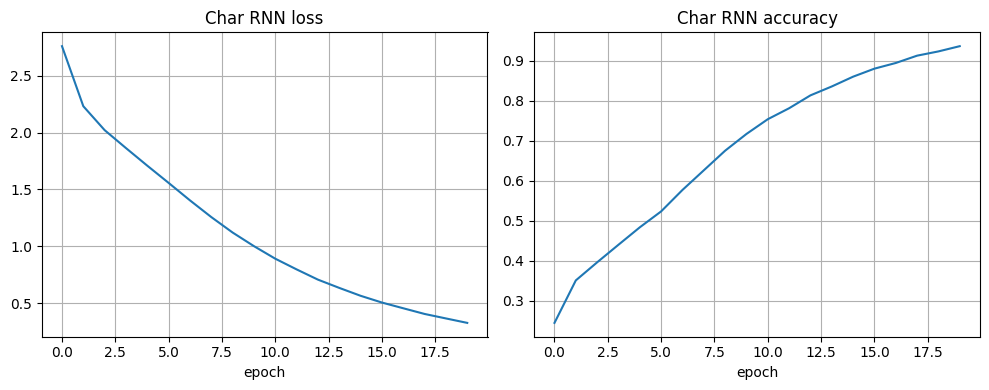

Char LSTM history:


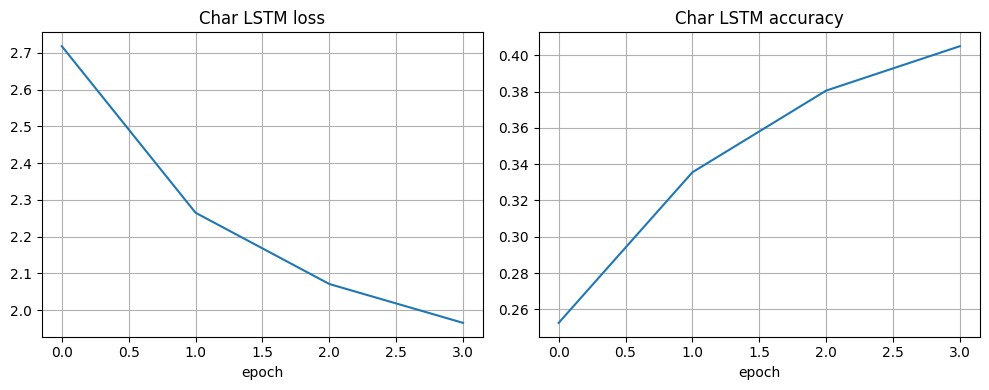

In [8]:
# CELL 8 - train char-level RNN and LSTM with callbacks and plot loss/accuracy
es = callbacks.EarlyStopping(monitor='loss', patience=4, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

history_rnn = model_char_rnn.fit(dataset_char, epochs=EPOCHS_CHAR, callbacks=[es, rlr], verbose=1)
history_lstm = model_char_lstm.fit(dataset_char, epochs=EPOCHS_CHAR, callbacks=[es, rlr], verbose=1)

# plotting helper
def plot_history(h, title="History"):
    plt.figure(figsize=(10,4))
    if 'loss' in h.history:
        plt.subplot(1,2,1); plt.plot(h.history['loss'], label='loss'); plt.title(title+" loss"); plt.xlabel('epoch'); plt.grid(True)
    if 'accuracy' in h.history:
        plt.subplot(1,2,2); plt.plot(h.history['accuracy'], label='acc'); plt.title(title+" accuracy"); plt.xlabel('epoch'); plt.grid(True)
    plt.tight_layout(); plt.show()

print("Char RNN history:")
plot_history(history_rnn, "Char RNN")
print("Char LSTM history:")
plot_history(history_lstm, "Char LSTM")

Epoch 1/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0636 - loss: 5.9443 - learning_rate: 0.0010
Epoch 2/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0685 - loss: 5.5419 - learning_rate: 0.0010
Epoch 3/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0696 - loss: 5.3832 - learning_rate: 0.0010
Epoch 4/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0688 - loss: 5.1963 - learning_rate: 0.0010
Epoch 5/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0733 - loss: 5.0454 - learning_rate: 0.0010
Epoch 6/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0856 - loss: 4.8856 - learning_rate: 0.0010
Epoch 7/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1064 - loss: 4.6928 - learning_rate: 0.0010
Epoch 8/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1280 - loss: 4.4730 - learning_rate: 0.0010
Epoch 9/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1540 - loss: 4.1982 - learning_rate: 0.0010
Epoch 10/25
42/42 ━━━━━━━

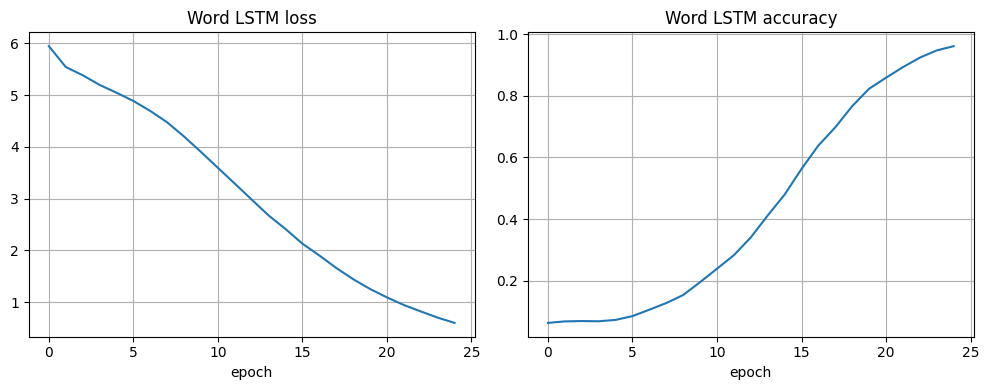

In [9]:
# CELL 9 - train word-level LSTM
es_w = callbacks.EarlyStopping(monitor='loss', patience=4, restore_best_weights=True)
rlr_w = callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

history_word = model_word_lstm.fit(dataset_word, epochs=EPOCHS_WORD, callbacks=[es_w, rlr_w], verbose=1)
plot_history(history_word, "Word LSTM")

In [ ]:
# CELL 10 - text generation helpers
import numpy as np

def sample_probs(preds, temperature=1.0):
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-12) / (temperature + 1e-12)
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(preds), p=preds)

def generate_char_text(model, seed_text, length=400, temperature=1.0):
    
    seq = [char2idx.get(c, 0) for c in seed_text[-SEQ_LENGTH_CHAR:]]
    if len(seq) < SEQ_LENGTH_CHAR:
        seq = [0] * (SEQ_LENGTH_CHAR - len(seq)) + seq
    out = []
    seq_arr = np.array(seq, dtype=np.int32).reshape(1, SEQ_LENGTH_CHAR)
    for i in range(length):
        preds = model.predict(seq_arr, verbose=0)[0]
        idx = sample_probs(preds, temperature)
        ch = idx2char[idx]
        out.append(ch)
        seq_arr = np.roll(seq_arr, -1, axis=1)
        seq_arr[0, -1] = idx
    return "".join(out)

def generate_word_text(model, tokenizer, seed_words, length=50):

    ids = tokenizer.texts_to_sequences([seed_words])[0]
    if len(ids) < SEQ_LENGTH_WORD:
        ids = [0]*(SEQ_LENGTH_WORD - len(ids)) + ids
    out_words = []
    seq = ids[-SEQ_LENGTH_WORD:]
    for i in range(length):
        preds = model.predict(np.array(seq).reshape(1, SEQ_LENGTH_WORD), verbose=0)[0]
        idx = int(np.argmax(preds))
        word = tokenizer.index_word.get(idx, "<OOV>")
        out_words.append(word)
        seq = seq[1:] + [idx]
    return " ".join(out_words)

In [12]:
# CELL 12 - small experiments: learning rate and batch size influence on char-LSTM
from tabulate import tabulate

def quick_train_char_lstm(lr, batch_size, epochs=2):
    m = build_char_lstm(vocab_size_char, emb_dim=64, lstm_units=128)
    opt = optimizers.Adam(learning_rate=lr, clipnorm=1.0)
    m.compile(optimizer=opt, loss='sparse_categorical_crossentropy')
    ds = tf.data.Dataset.from_tensor_slices((inputs, targets)).shuffle(5000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    h = m.fit(ds, epochs=epochs, verbose=0)
    return h.history['loss'][-1]

lrs = [0.01, 0.001, 0.0005]
batches = [32, 64]
results = []
for lr in lrs:
    for bs in batches:
        loss_end = quick_train_char_lstm(lr, bs)
        results.append((lr, bs, loss_end))
print(tabulate(results, headers=["lr","batch_size","final_loss"], tablefmt="github"))

|     lr |   batch_size |   final_loss |
|--------|--------------|--------------|
| 0.01   |           32 |      1.77229 |
| 0.01   |           64 |      1.7015  |
| 0.001  |           32 |      2.27016 |
| 0.001  |           64 |      2.3953  |
| 0.0005 |           32 |      2.50842 |
| 0.0005 |           64 |      2.61015 |


In [13]:
# CELL 13 - save models and outputs
os.makedirs("saved_models", exist_ok=True)
model_char_rnn.save("saved_models/char_rnn.keras")
model_char_lstm.save("saved_models/char_lstm.keras")
model_word_lstm.save("saved_models/word_lstm.keras")
print("Saved models to saved_models/")

# save training histories
import json
def dump_hist(h, name):
    if h is None: return
    with open(f"{name}_history.json","w") as f:
        json.dump(h.history, f)
dump_hist(history_rnn, "char_rnn")
dump_hist(history_lstm, "char_lstm")
dump_hist(history_word, "word_lstm")

print("Saved histories and generated text files in notebook folder.")

Saved models to saved_models/
Saved histories and generated text files in notebook folder.


## Observations:

LSTM typically shows slower training per epoch but better stability and more coherent generated text compared to a SimpleRNN.

Larger learning rates (e.g., 0.01) may cause unstable training/loss; lower rates (0.001 or 0.0005) are typically safer. The experiment table (CELL 12) shows final loss for each setting.

Increasing SEQ_LENGTH gives the model more context to learn long-range structure but increases compute and memory usage.

Word-level models capture semantic content better (actual words, grammar) while char-level models learn orthography and local punctuation patterns — allow different types of generation